In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

import scopesim as sim
from scopesim.utils import from_currsys
import scopesim_templates as sim_tp
import importlib.resources
import pathlib

## configure path
try:
    irdb_path = str(pathlib.Path(importlib.resources.files('irdb')).parent)
except ModuleNotFoundError:
    irdb_path = "/Users/yashvi/Desktop/ZShooter/irdb/"

sim.rc.__config__["!SIM.file.local_packages_path"] = irdb_path
sim.rc.__config__["!SIM.file.search_path"].append(irdb_path)
## configure log level
sim.utils.set_console_log_level("DEBUG")

py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## Load a simulation config appropriate for your tests.
- Any instrument config can be used here that already defines the simulation parameters and some basic necessary effects (primarily aperture and detector related effects).
- Depending on your test, you can either instantiate the full optical train from the loaded instrument config and use the loaded fovs, detectors, effects etc. OR
- Just load the user commands and instantiate fovs, image plane, detector and effects with custom parameters separately.

I'm using ZShooter config below but for the effects being tested (PSF, ADC) a simpler basic site/telescope/instrument config with just an aperture and detector would also work. For the latter you will need to write config yamls. What I'm demonstrating below is how to do that without writing yamls by directly instantiating necessary objects and effects.

In [2]:
# Load zshooter configs for sim cmds
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
# init optica manager if we need to load and use any effects from this config
optman = sim.optics.OpticsManager(cmd.yaml_dicts, cmd)

astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-05-16T10:21:53.856.
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-05-16T10:21:53.856.
astar.scopesim.effects.sky_ter_curves - WARNING: Local time is outside of the range covered by the PALACE model (18-6h). Defaulting to tbin=0 (all times).
astar.scopesim.effects.psfs.analytical - using seeing and natural scale for FWHM
astar.scopesim.effects.psfs.analytical - Using !OBS.alt to determine zenith angle.
astar.scopesim.effects.ter_curves - Loading dichroic bgr-yjhk from dichroics/TER_dichroic_bgr-yjhk.dat
astar.scopesim.effects.ter_curves - Loading dichroic b-gr from dichroics/TER_dichroic_b-gr.dat

In [3]:
# instantiate effects
## source effect (for simulating telescope photon collection)
teleff = [eff for eff in optman.all_effects if eff.display_name=='telescope_reflection'][0]

## simple aperture mask for making initial fov
from scopesim.effects.apertures import RectangularApertureMask
apeff = RectangularApertureMask(x=0, y=0, width=10, height=10, x_unit="arcsec", y_unit="arcsec", cmds=cmd)

## simple detector list effect for setting an image plane
from scopesim.effects.detector_list import DetectorList
deteff = DetectorList(image_plane_id=0, array_dict={'id':[0], 'x_cen':[0], 'y_cen':[0], 'x_size':[100], 'y_size':[100],
                                                    'pixel_size':[0.015], 'angle':[0], 'gain':[1]},
                      x_cen_unit='mm', y_cen_unit='mm', pixel_size_unit='mm', x_size_unit='pix', y_size_unit='pix',
                      angle_unit='deg', gain_unit='electron/adu', cmds=cmd)

## effects to test
from scopesim.effects.psfs.analytical import MoffatPSF
mpsf = MoffatPSF(seeing=0.7, seeing_unit="arcsec", pivot_wave=500., pivot_wave_unit="nm", alpha=4.765, enable_ao=False,
                 cmds=cmd)

astar.scopesim.effects.psfs.analytical - using seeing and natural scale for FWHM
astar.scopesim.effects.psfs.analytical - Using !OBS.alt to determine zenith angle.


In [4]:
# initialize fovs using the simple aperture and detector effects, this is the first step in the optical train
from scopesim.optics.fov_manager import FOVManager
fovman = FOVManager(effects=[apeff], cmds=cmd)
fovman.fovs[0]

astar.scopesim.optics.fov_manager - Generating initial fovs_list.
astar.scopesim.effects.apertures - Executing <empty>, FoV setup
astar.scopesim.optics.fov_manager - Returning existing fovs_list.


FieldOfView2D(NAXIS   =                    2                                                  
NAXIS1  =                   63                                                  
NAXIS2  =                   63                                                  
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =                 32.0 / Pixel coordinate of reference point            
CRPIX2  =                 32.0 / Pixel coordinate of reference point            
CDELT1  =  4.4326241134722E-05 / [deg] Coordinate increment at reference point  
CDELT2  =  4.4326241134722E-05 / [deg] Coordinate increment at reference point  
CUNIT1  = 'deg'                / Units of coordinate increment and value        
CUNIT2  = 'deg'                / Units of coordinate increment and value        
CTYPE1  = 'LINEAR'             / Coordinate type code                           
CTYPE2  = 'LINEAR'             / Coordinate type code                           
CRVAL1  = -7.3

astar.scopesim.optics.fov_manager - Returning existing fovs_list.
astar.scopesim.optics.fov_manager - Returning existing fovs_list.


<Axes: xlabel='x [arcsec]', ylabel='y [arcsec]'>

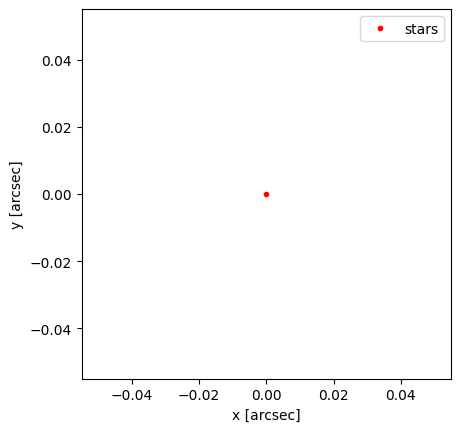

In [5]:
# create and prepare source
from scopesim.source.source_fields import SpectrumSourceField
from scopesim.source.source_utils import SourceSpectrum, Empirical1D

# create source
## 'Source' objects store a list of SourceField objects
source = sim_tp.star(filter_name='V', amplitude=10*u.ABmag)

# prepare source (snippet taken from OpticalTrain().prepare_source())
for field in source.fields:
    if not isinstance(field, SpectrumSourceField):
        continue
    for ispec, spec in field.spectra.items():
        # Put on fov wavegrid
        wave_min = min(fov.meta["wave_min"] for fov in fovman.fovs)
        wave_max = max(fov.meta["wave_max"] for fov in fovman.fovs)
        wave_unit = u.Unit(from_currsys("!SIM.spectral.wave_unit", cmd))
        dwave = from_currsys("!SIM.spectral.spectral_bin_width", cmd)  # Not a quantity
        fov_waveset = np.arange(wave_min.value, wave_max.value, dwave) * wave_unit
        fov_waveset = fov_waveset.to(u.um)

        field.spectra[ispec] = SourceSpectrum(Empirical1D,
                                              points=fov_waveset,
                                              lookup_table=spec(fov_waveset))

source.plot()

astar.scopesim.optics.fov_manager - Returning existing fovs_list.
astar.scopesim.optics.fov - 2 fields in FOV


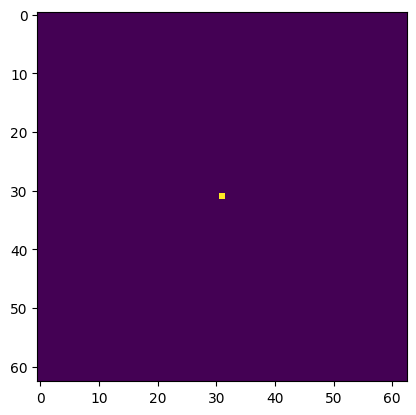

In [6]:
# apply source effects to get the source as it enters the telescope aperture
source = teleff.apply_to(source)
# extract source to fov
fov = fovman.fovs[0]
fov.extract_from(source)
fov.view()  # puts all 'fields' in the source as one object
plt.imshow(fov.data)

astar.scopesim.effects.psfs.psf_base - Executing <empty>, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done


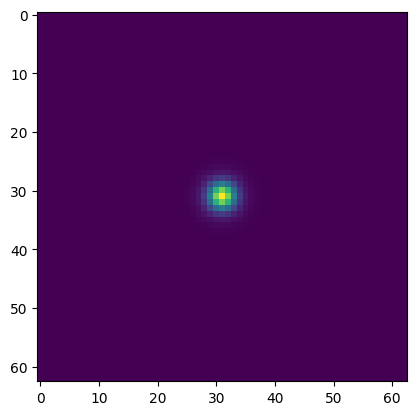

In [7]:
# apply psf effect
fov = mpsf.apply_to(fov)
plt.imshow(fov.data)

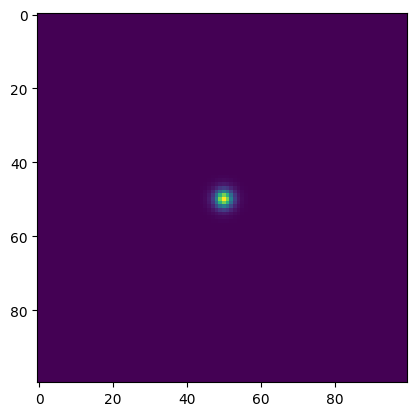

In [8]:
# flatten because we just want to see the spatial data for this test
fov.flatten()
# create image plane
from scopesim.optics.image_plane import ImagePlane
hdr = deteff.image_plane_header # hdr is needed
im = ImagePlane(hdr, cmds=cmd)
# add fov hdu to image plane
im.add(fov.hdu, wcs_suffix="D")
plt.imshow(im.data)

## Testing ADC effect
The above steps can be repeated for any effects that only deal with FoV2D. Since ADC applies to a FoV3D, we need to create that by applying a `SpectralTraceList()` effect along with aperture effect.

In [9]:
# Load zshooter configs for sim cmds
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
# init optica manager if we need to load and use any effects from this config
optman = sim.optics.OpticsManager(cmd.yaml_dicts, cmd)

astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-05-16T10:21:53.856.
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-05-16T10:21:53.856.
astar.scopesim.effects.sky_ter_curves - WARNING: Local time is outside of the range covered by the PALACE model (18-6h). Defaulting to tbin=0 (all times).
astar.scopesim.effects.psfs.analytical - using seeing and natural scale for FWHM
astar.scopesim.effects.psfs.analytical - Using !OBS.alt to determine zenith angle.
astar.scopesim.effects.ter_curves - Loading dichroic bgr-yjhk from dichroics/TER_dichroic_bgr-yjhk.dat
astar.scopesim.effects.ter_curves - Loading dichroic b-gr from dichroics/TER_dichroic_b-gr.dat

In [10]:
# instantiate effects
## source effect (for simulating telescope photon collection)
teleff = [eff for eff in optman.all_effects if eff.display_name=='telescope_reflection'][0]

## simple aperture mask for making initial fov
from scopesim.effects.apertures import RectangularApertureMask
apeff = RectangularApertureMask(x=0, y=0, width=10, height=10, x_unit="arcsec", y_unit="arcsec", cmds=cmd)

## simple detector list effect for setting an image plane
from scopesim.effects.detector_list import DetectorList
deteff = DetectorList(image_plane_id=0, array_dict={'id':[0], 'x_cen':[0], 'y_cen':[0], 'x_size':[100], 'y_size':[100],
                                                    'pixel_size':[0.015], 'angle':[0], 'gain':[1]},
                      x_cen_unit='mm', y_cen_unit='mm', pixel_size_unit='mm', x_size_unit='pix', y_size_unit='pix',
                      angle_unit='deg', gain_unit='electron/adu', cmds=cmd)

# initialize spectral trace list effect
from scopesim.effects.spectral_trace_list import SpectralTraceList
from astropy.io import fits
from astropy.table import Table
hdul = fits.HDUList([
    fits.PrimaryHDU(header=fits.Header(cards={'ECAT':1,'EDATA':2})),
    fits.BinTableHDU(data=Table(data={'description':['test'], 'extension_id':[2], 'aperture_id':[0], 'image_plane_id':[0]})),
    fits.BinTableHDU(header=fits.Header(cards={'EXTNAME':'test'}), data=Table(data={'wavelength':[0.3, 0.5, 0.3, 0.5, 0.3, 0.5], 's': [-2, -2, 0, 0, 2, 2], 'x':[3.0, 3.0, 3.5, 3.5, 4.0, 4.0], 'y':[0.1, 7.4, 0.1, 7.4, 0.1, 7.4]}))
])
stleff = SpectralTraceList(hdulist=hdul, cmds=cmd)

# initialize fovs using the simple aperture effect and spectraltracelist effect, this is the first step in the optical train
from scopesim.optics.fov_manager import FOVManager
fovman = FOVManager(effects=[apeff, stleff, deteff], cmds=cmd)
fovman.fovs[0]

astar.scopesim.effects.spectral_trace_list_utils - Dispersion axis determined to be y
py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/ScopeSim/scopesim/effects/spectral_trace_list.py:165: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

astar.scopesim.optics.fov_manager - Generating initial fovs_list.
astar.scopesim.effects.apertures - Executing <empty>, FoV setup
astar.scopesim.effects.spectral_trace_list - <empty> applied to FovVolumeList
py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/ScopeSim/scopesim/effects/spectral_trace_list.py:207: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

astar.scopesim.effects.spectral_trace_list - <empty> done
astar.scopesim.effects.detector_list - apply_to got kwargs: {'pixel_scale': '!INST.pixel_scale'}
astar.scopesim.optics.fov_manager - Returning existing fovs_list.


FieldOfView3D(NAXIS   =                    2                                                  
NAXIS1  =                   63                                                  
NAXIS2  =                   63                                                  
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =                 32.0 / Pixel coordinate of reference point            
CRPIX2  =                 32.0 / Pixel coordinate of reference point            
CDELT1  =  4.4326241134722E-05 / [deg] Coordinate increment at reference point  
CDELT2  =  4.4326241134722E-05 / [deg] Coordinate increment at reference point  
CUNIT1  = 'deg'                / Units of coordinate increment and value        
CUNIT2  = 'deg'                / Units of coordinate increment and value        
CTYPE1  = 'LINEAR'             / Coordinate type code                           
CTYPE2  = 'LINEAR'             / Coordinate type code                           
CRVAL1  = -7.3

In [11]:
# create and prepare source
from scopesim.source.source_fields import SpectrumSourceField
from scopesim.source.source_utils import SourceSpectrum, Empirical1D

# create source
## 'Source' objects store a list of SourceField objects
source = sim_tp.star(filter_name='V', amplitude=10*u.ABmag)

# prepare source (snippet taken from OpticalTrain().prepare_source())
for field in source.fields:
    if not isinstance(field, SpectrumSourceField):
        continue
    for ispec, spec in field.spectra.items():
        # Put on fov wavegrid
        wave_min = min(fov.meta["wave_min"] for fov in fovman.fovs)
        wave_max = max(fov.meta["wave_max"] for fov in fovman.fovs)
        wave_unit = u.Unit(from_currsys("!SIM.spectral.wave_unit", cmd))
        dwave = from_currsys("!SIM.spectral.spectral_bin_width", cmd)  # Not a quantity
        fov_waveset = np.arange(wave_min.value, wave_max.value, dwave) * wave_unit
        fov_waveset = fov_waveset.to(u.um)

        field.spectra[ispec] = SourceSpectrum(Empirical1D,
                                              points=fov_waveset,
                                              lookup_table=spec(fov_waveset))

astar.scopesim.optics.fov_manager - Returning existing fovs_list.
astar.scopesim.optics.fov_manager - Returning existing fovs_list.


In [12]:
# apply source effects to get the source as it enters the telescope aperture
source = teleff.apply_to(source)
# extract source to fov
fov = fovman.fovs[0]
fov.extract_from(source)
fov.view()  # puts all 'fields' in the source as one object

astar.scopesim.optics.fov_manager - Returning existing fovs_list.
astar.scopesim.optics.fov - 2 fields in FOV


In [13]:
## effects to test
from scopesim.effects.psfs.analytical import MoffatPSF
mpsf = MoffatPSF(seeing=0.7, seeing_unit="arcsec", pivot_wave=500., pivot_wave_unit="nm", alpha=4.765, enable_ao=False,
                 cmds=cmd)

from scopesim.effects.atmo_dispersion import ADShift, ADCShift
adeff = ADShift(cmds=cmd, temperature=15, pressure=1.01325, humidity=0.0, target={'alt':30,'az':180}, mjdobs=61155.0,
                wave_ref_um=0.5, method='roll')
adceff = ADCShift(cmds=cmd, target={'alt':30,'az':180}, mjdobs=61155.0, wave_ref_um=0.5, method='roll', zenith_angle_error=0.9,
                  filename='/Users/yashvi/Desktop/ZShooter/irdb/MaunaKea/adc_residuals.dat')

astar.scopesim.effects.psfs.analytical - using seeing and natural scale for FWHM
astar.scopesim.effects.psfs.analytical - Using !OBS.alt to determine zenith angle.
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-04-25T10:21:53.856.
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-04-25T10:21:53.856.


astar.scopesim.effects.psfs.psf_base - Executing <empty>, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done


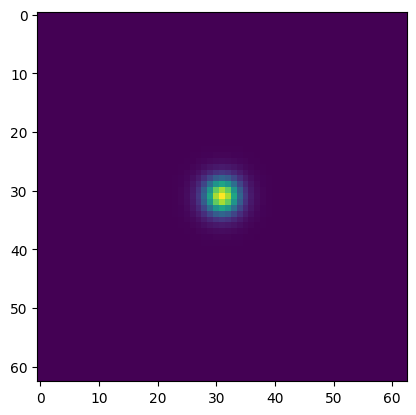

In [14]:
# apply effects
fov = mpsf.apply_to(fov)
plt.imshow(np.sum(fov.data,axis=0))

astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured counter-clockwise from +y axis is 0.


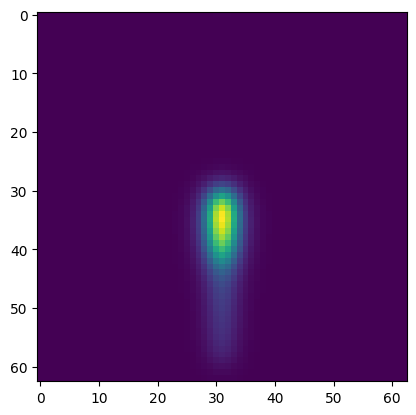

In [15]:
from copy import copy
fovad = adeff.apply_to(copy(fov))
plt.imshow(np.sum(fovad.data,axis=0))

Zenith direction here is along the North (which is aligned with +y axis), so the shift is expected to be towards increasing y values.

astar.scopesim.effects.atmo_dispersion - Residuals supplied by /Users/yashvi/Desktop/ZShooter/irdb/MaunaKea/adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.9
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-04-25T10:21:53.856.


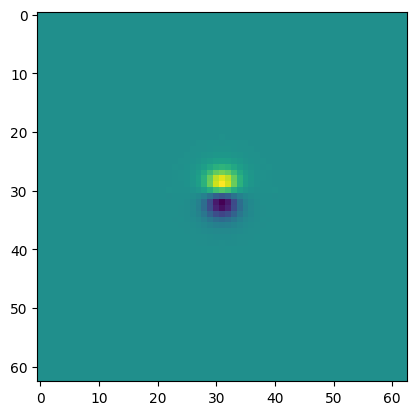

In [16]:
fovadc = adceff.apply_to(copy(fov))
plt.imshow(np.sum(fovadc.data,axis=0) - np.sum(fov.data,axis=0))